## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import theilslopes, linregress

## 2. Load .csv

In [2]:
df = pd.read_csv('ee-chart.csv')
df.head()

,date,meanDSWE
0,2018_12,0.030
1,2019_01,0.035
2,2019_02,0.045
3,2019_03,0.051
4,2019_04,0.056


## 3. Plot Mean DSWE

In [3]:
# Parameters
df['monthIndex'] = np.arange(len(df))    

x = df['monthIndex'].values
y = df['meanDSWE'].values

print(x)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75]


In [4]:
bestfit = linregress(x, y)

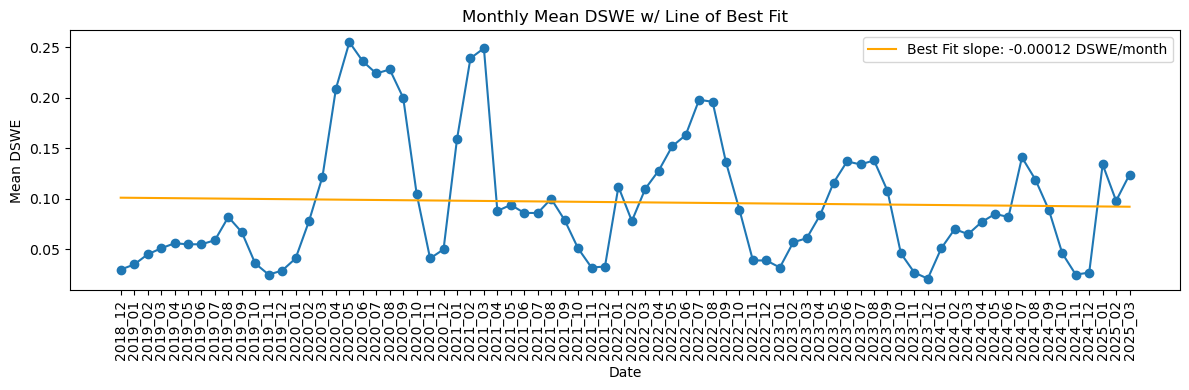

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, y, marker='o', linestyle='-')
ax.plot(x,
        (bestfit.slope * x) + bestfit.intercept,
        color='orange',
        label=f"Best Fit slope: {bestfit.slope:.5f} DSWE/month")

ax.set_title('Monthly Mean DSWE w/ Line of Best Fit')
ax.set_xlabel('Date')
ax.set_ylabel('Mean DSWE')
ax.legend()

ax.set_xticks(x) # set every date as a tick
ax.set_xticklabels(df['date'], rotation=90)

plt.tight_layout()
plt.show()

## 4. Define Sen's Slope
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mstats.theilslopes.html

In [6]:
def compute_sen(x, y, alpha=0.95):
    slope, intercept, low_slope, high_slope = theilslopes(y, x, alpha=alpha)
    return slope, intercept, low_slope, high_slope

## 5. Full Sen's Slope Time Series

In [7]:
slope_full, intercept_full, low_full, high_full = compute_sen(x, y)

print(f"Sen's slope: {slope_full:.6f} DSWE/month")
print(f"Intercept: {intercept_full:.6f}")
print(f"95% CI slope: [{low_full:.6f}, {high_full:.6f}]")

Sen's slope: 0.000148 DSWE/month
Intercept: 0.077461
95% CI slope: [-0.000414, 0.000706]


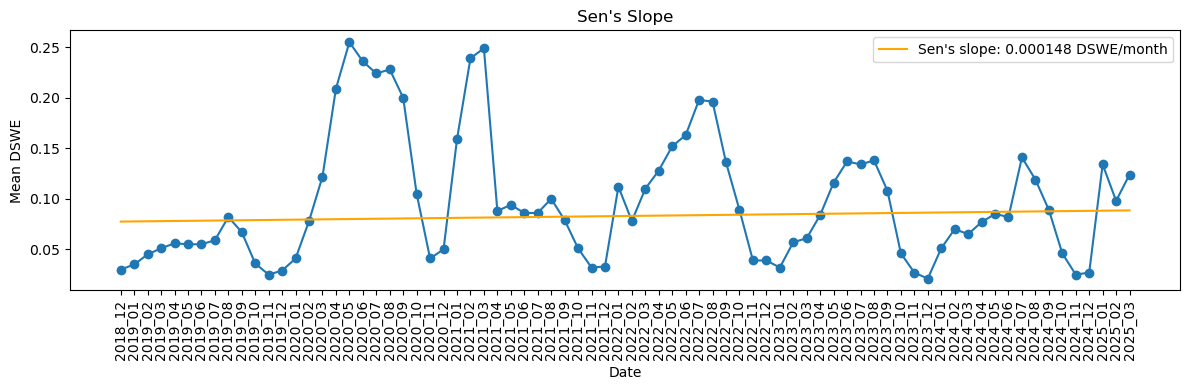

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, y, marker='o', linestyle='-')
ax.plot(x,
        slope_full*x + intercept_full,
        color='orange', 
        label=f"Sen's slope: {slope_full:.6f} DSWE/month")

ax.set_title("Sen's Slope")
ax.set_xlabel('Date')
ax.set_ylabel('Mean DSWE')
ax.legend()

ax.set_xticks(x) # set every date as a tick
ax.set_xticklabels(df['date'], rotation=90)

plt.tight_layout()
plt.show()

## 6.

In [9]:
df['datetime'] = pd.to_datetime(df['date'], format='%Y_%m')
df['month'] = df['datetime'].dt.month

df.head()

,date,meanDSWE,monthIndex,datetime,month
0,2018_12,0.030,0,2018-12-01,12
1,2019_01,0.035,1,2019-01-01,1
2,2019_02,0.045,2,2019-02-01,2
3,2019_03,0.051,3,2019-03-01,3
4,2019_04,0.056,4,2019-04-01,4


In [10]:
monthWindow = [7,8,9] # Months to include

df_monthWindow = df[df['month'].isin(monthWindow)].copy()
df_monthWindow.reset_index(drop=True, inplace=True)
x_window = df_monthWindow['monthIndex'].values
y_window = df_monthWindow['meanDSWE'].values

df_monthWindow.tail()

,date,meanDSWE,monthIndex,datetime,month
13,2023_08,0.138,56,2023-08-01,8
14,2023_09,0.108,57,2023-09-01,9
15,2024_07,0.141,67,2024-07-01,7
16,2024_08,0.119,68,2024-08-01,8
17,2024_09,0.089,69,2024-09-01,9


In [11]:
slope_window, intercept_window, low_window, high_window = compute_sen(x_window, y_window)
print(f"Sen's slope: {slope_window:.6f} DSWE/month")
print(f"Intercept: {intercept_window:.6f}")
print(f"95% CI slope: [{low_window:.6f}, {high_window:.6f}]")

Sen's slope: 0.000227 DSWE/month
Intercept: 0.117864
95% CI slope: [-0.002143, 0.001171]


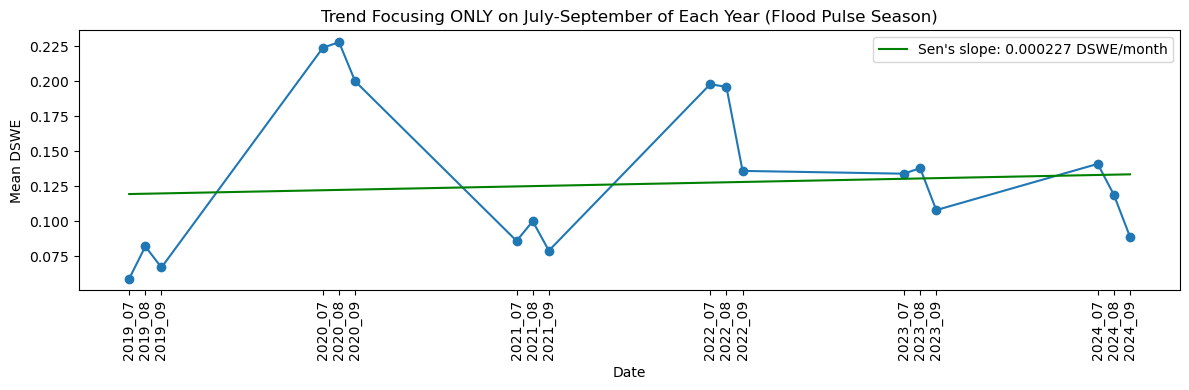

In [12]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(x_window, y_window, marker='o', linestyle='-')
ax.plot(
    x_window,
    intercept_window + slope_window * x_window,
    color='green', linestyle='-',
    label=f"Sen's slope: {slope_window:.6f} DSWE/month"
)

ax.set_title('Trend Focusing ONLY on July-September of Each Year (Flood Pulse Season)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean DSWE')
ax.legend()

ax.set_xticks(x_window)
ax.set_xticklabels(df_monthWindow['date'], rotation=90)

plt.tight_layout()
plt.show()
